In [17]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import cudf
from cuml import UMAP

In [18]:
# Load the data



# data = pd.read_csv('../../../data/resample_normalized.csv')

data = pd.read_csv('../../../data/resample_normalized_flagged_v3.csv')

# drop collumn "STARFLAGS"
data = data.drop(columns=['STARFLAGS'])

display(data.columns)
data_id = data['apogee_id']

data_target = data[['class_spectral',
                    'class_lum_logg', 'class_lum_jhk', 'class_lum_bins_logg',
                    'class_lum_bins_jhk']]

# Suppression des colonnes non souhaitées
data = data.drop(columns=['M_H', 'VMICRO', 'VMACRO', 'J', 'H', 'K', 'LOGG',
                          'apogee_id', 'class_spectral',
                          'class_lum_logg', 'class_lum_jhk', 'class_lum_bins_logg',
                          'class_lum_bins_jhk'])

# apply standard scaler to data
scaler = MinMaxScaler()
#scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)


data_cudf = cudf.DataFrame(data_scaled)

Index(['apogee_id', 'J', 'H', 'K', 'LOGG', 'M_H', 'VMICRO', 'VMACRO', 'C_FE',
       'CI_FE', 'N_FE', 'O_FE', 'NA_FE', 'MG_FE', 'AL_FE', 'SI_FE', 'S_FE',
       'K_FE', 'CA_FE', 'TI_FE', 'V_FE', 'CR_FE', 'MN_FE', 'NI_FE', 'FE_H',
       'class_spectral', 'class_lum_logg', 'class_lum_jhk',
       'class_lum_bins_logg', 'class_lum_bins_jhk'],
      dtype='object')

In [19]:

# Création et ajustement du modèle UMAP en 2D
umap = UMAP(n_components=2, random_state=42, n_neighbors=80, min_dist=0.005, verbose=True)
embedding = umap.fit_transform(data_cudf)

# Conversion du résultat en DataFrame pandas
embedding = embedding.to_pandas()
print(embedding.head())


[2025-02-28 18:27:45.211] [CUML] [info] build_algo set to brute_force_knn because random_state is given
[2025-02-28 18:27:45.293] [CUML] [debug] n_neighbors=80
[2025-02-28 18:27:45.298] [CUML] [debug] Calling knn graph run
[2025-02-28 18:28:00.556] [CUML] [debug] Done. Calling fuzzy simplicial set
[2025-02-28 18:28:00.597] [CUML] [debug] Smooth kNN Distances
[2025-02-28 18:28:00.598] [CUML] [debug] Compute Membership Strength
[2025-02-28 18:28:01.087] [CUML] [debug] Done. Calling remove zeros
          0         1
0  1.311554 -2.722773
1  3.377579  2.106116
2  3.378541  2.110843
3 -2.744236  1.055195
4 -6.730627 -2.078399


In [20]:
embedding.describe()

,0,1
count,453952.000000,453952.000000
mean,-0.140394,-0.055893
std,5.728692,5.738225
min,-155.492630,-158.650116
25%,-4.270972,-2.504790
50%,0.375033,1.348143
75%,3.858529,3.826368
max,123.028732,137.418304


In [21]:
#count nan
print(embedding.isna().sum())

0    0
1    0
dtype: int64


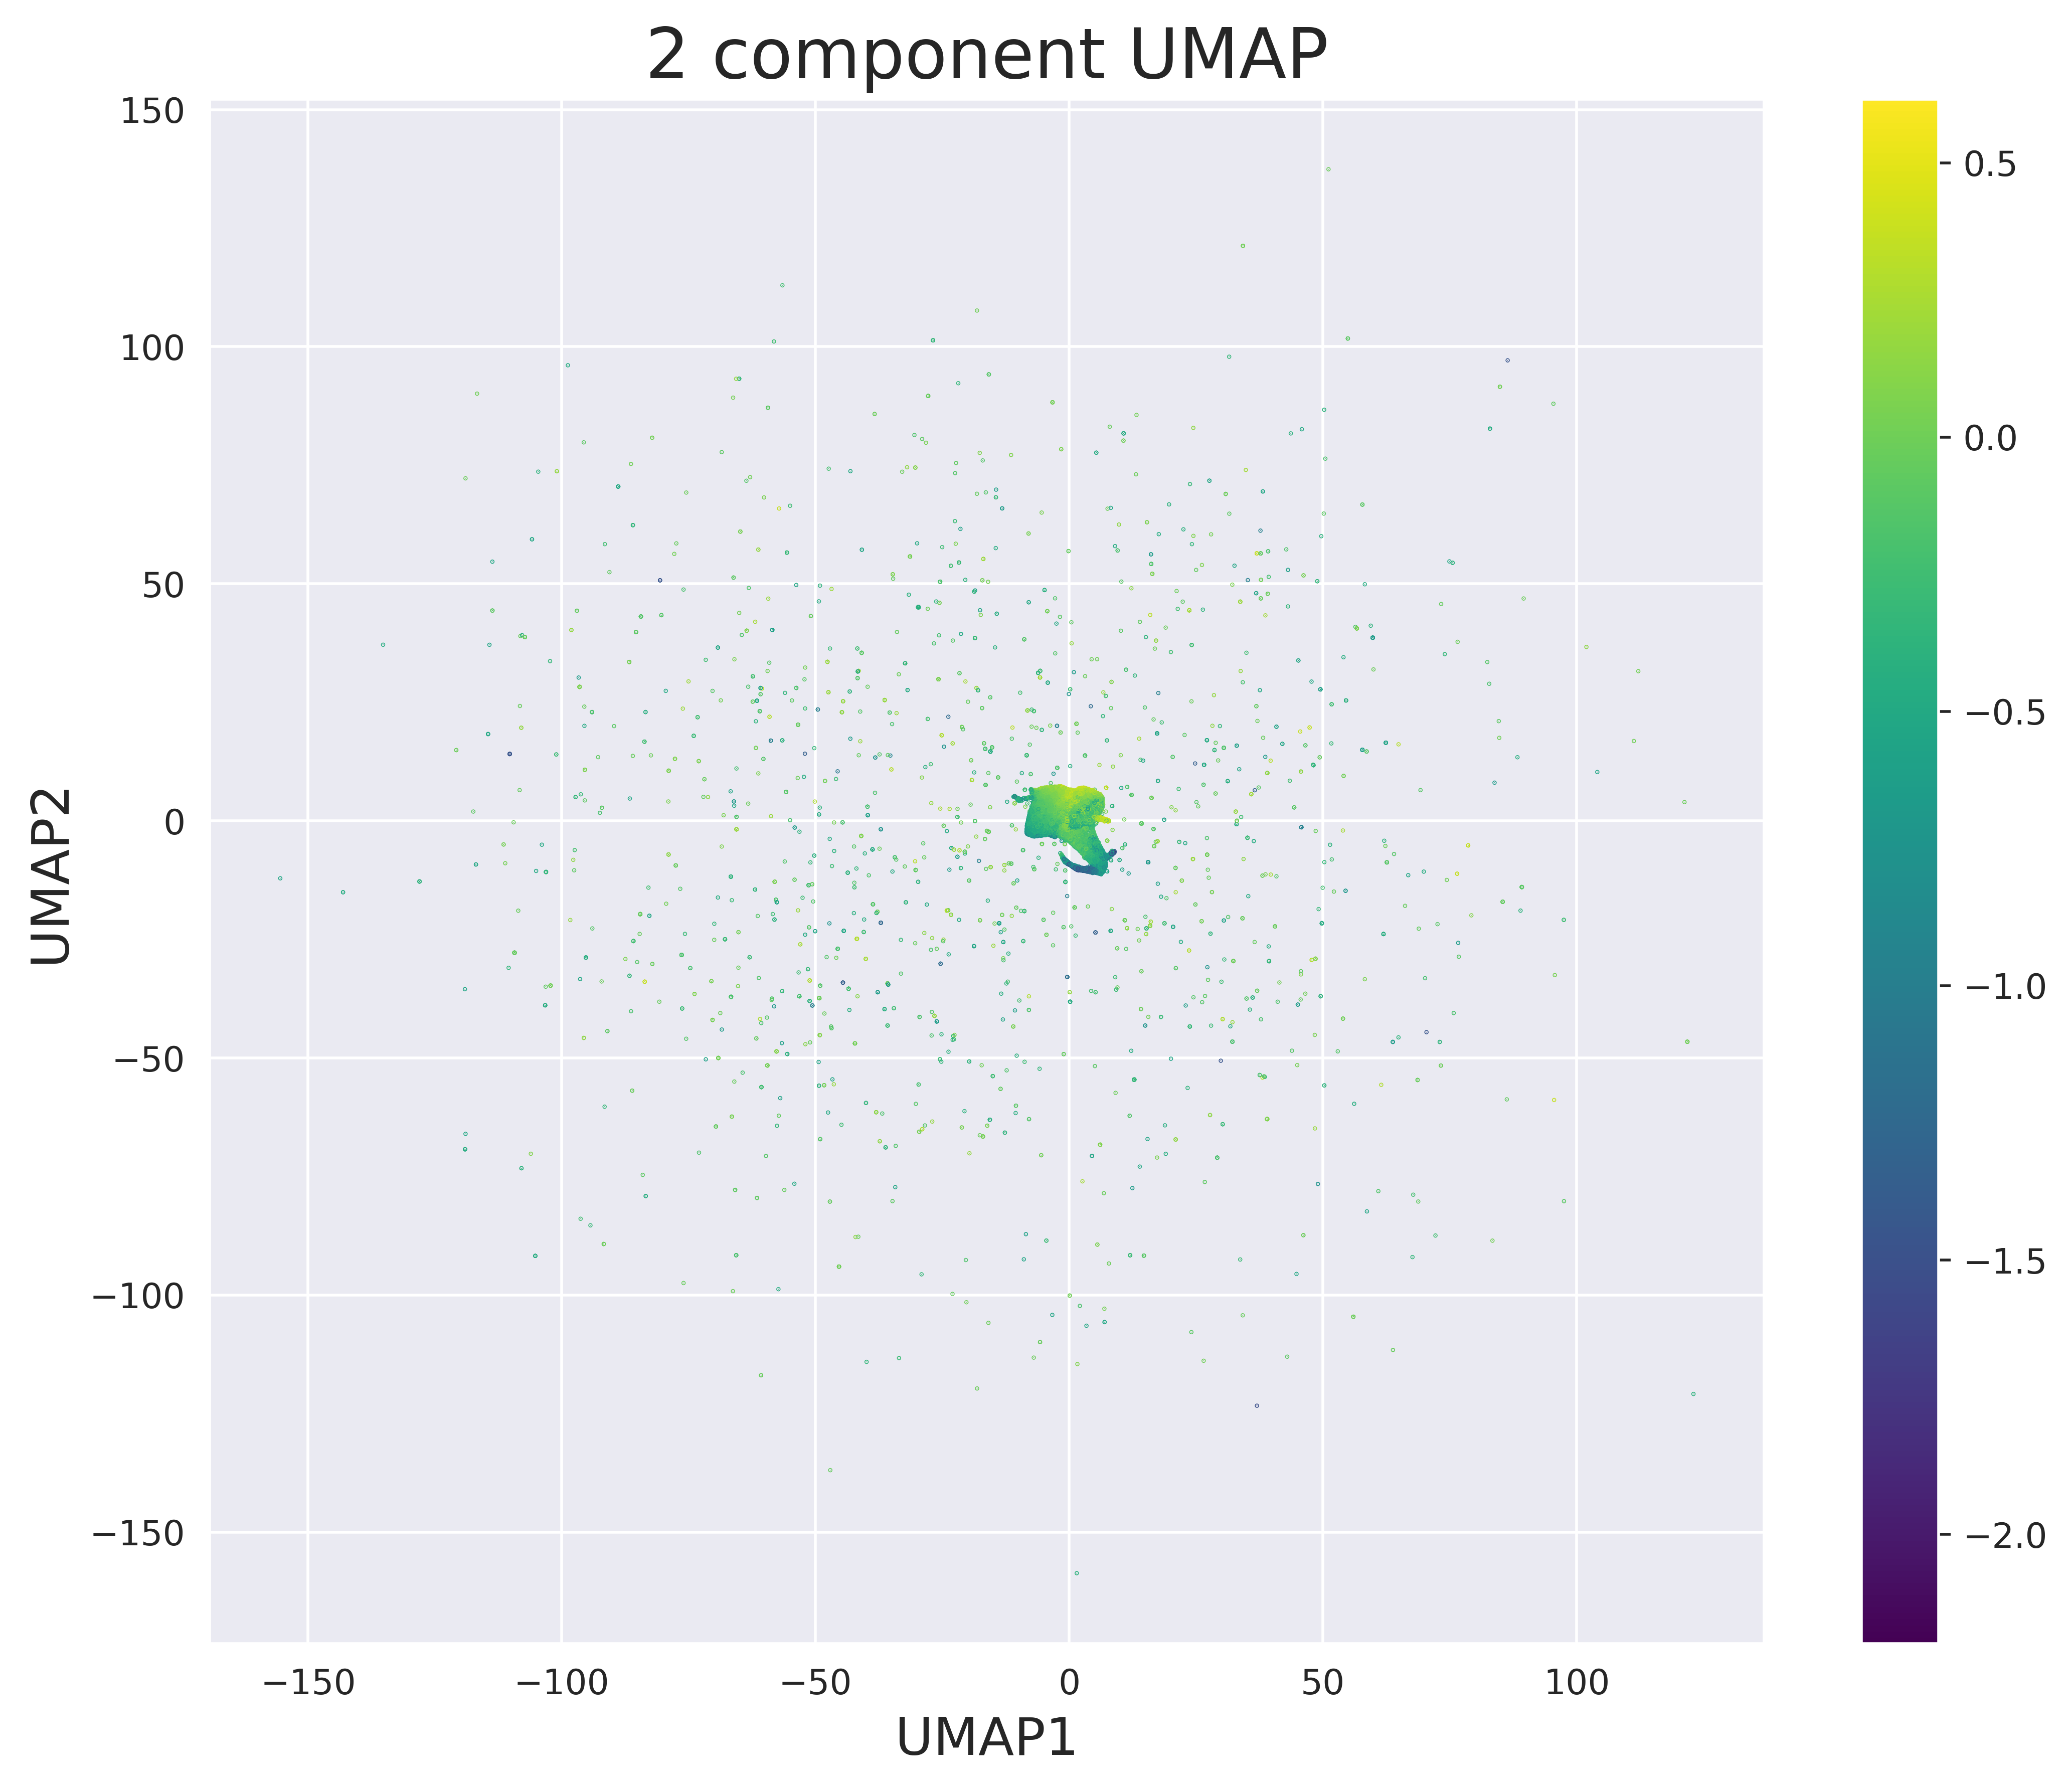

In [22]:
# Plot the PCA result
fig = plt.figure(figsize=(10,8), dpi=500)
ax = fig.add_subplot(1, 1, 1)
ax.set_xlabel('UMAP1', fontsize=15)
ax.set_ylabel('UMAP2', fontsize=15)
ax.set_title('2 component UMAP', fontsize=20)
# Create the scatter plot with color gradient from FE_H
scatter = ax.scatter(embedding[0], embedding[1], c=data['FE_H'], cmap='viridis', s=0.05)
plt.colorbar(scatter)
plt.show()


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Si vous utilisez cuML (GPU)
from cuml.cluster import DBSCAN

# Imaginons que "embedding" soit votre projection UMAP, sous forme d'un DataFrame cudf ou cupy array
# Si c'est un cudf.DataFrame, convertissons-le en pandas pour la visualisation:
embedding_pd = embedding # embedding = UMAP().fit_transform(...)
embedding_df = pd.DataFrame(embedding_pd, columns=['UMAP1','UMAP2'])

# Ajout de FE_H dans la table (si c'est un Series pandas)
embedding_df['FE_H'] = data['FE_H'].values

# Application de DBSCAN pour identifier les outliers
dbscan = DBSCAN(eps=5, min_samples=5)  # Ajustez eps et min_samples selon vos données
labels = dbscan.fit_predict(embedding_df[['UMAP1','UMAP2']])

# labels est un array GPU, convertissons-le en numpy/pandas
embedding_df['cluster_label'] = labels.to_pandas()

# Filtrage : on garde seulement les points qui ne sont pas considérés comme du bruit
embedding_df_filtered = embedding_df[embedding_df['cluster_label'] != -1]

# Visualisation
plt.figure(figsize=(10,8), dpi=500)
plt.title('UMAP filtré par DBSCAN')
scatter = plt.scatter(
    embedding_df_filtered['UMAP1'],
    embedding_df_filtered['UMAP2'],
    c=embedding_df_filtered['FE_H'],
 cmap='viridis', s=0.05
)
plt.colorbar(scatter, label='FE_H')
plt.xlabel('UMAP1')
plt.ylabel('UMAP2')
plt.show()


AttributeError: 'Series' object has no attribute 'to_pandas'

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

import cudf
from sklearn.preprocessing import MinMaxScaler
from cuml import UMAP
from sklearn.cluster import DBSCAN  # version CPU de DBSCAN

# 1) Chargement et préparation des données
data = pd.read_csv('../../../data/resample_normalized_flagged_v3.csv')
data = data.drop(columns=['STARFLAGS'])  # on supprime la colonne "STARFLAGS"

data_id = data['apogee_id']
data_target = data[['class_spectral',
                    'class_lum_logg', 'class_lum_jhk', 'class_lum_bins_logg',
                    'class_lum_bins_jhk']]

# On supprime les colonnes non souhaitées pour la projection
data = data.drop(columns=['M_H', 'VMICRO', 'VMACRO', 'J', 'H', 'K', 'LOGG',
                          'apogee_id', 'class_spectral',
                          'class_lum_logg', 'class_lum_jhk', 'class_lum_bins_logg',
                          'class_lum_bins_jhk'])

# 2) Mise à l'échelle (MinMaxScaler)
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

# Conversion en DataFrame cuDF (pour UMAP sur GPU)
data_cudf = cudf.DataFrame(data_scaled)

# 3) Création et ajustement du modèle UMAP en 2D (cuML)
umap = UMAP(
    n_components=2,
    random_state=42,
    n_neighbors=80,
    min_dist=0.005,
    verbose=True
)
embedding_cudf = umap.fit_transform(data_cudf)

# 4) Conversion du résultat en DataFrame pandas
#    Les colonnes de 'embedding' s'appelleront 0 et 1.
embedding = embedding_cudf.to_pandas()

# 5) Détection des outliers avec DBSCAN (version CPU scikit-learn)
#    - eps et min_samples sont à ajuster selon la densité de vos données
dbscan = DBSCAN(eps=5, min_samples=10)
labels = dbscan.fit_predict(embedding[[0, 1]])  # on utilise les colonnes 0 et 1

# 6) Filtrage des outliers (points labelisés -1)
embedding['cluster_label'] = labels
embedding_filtered = embedding[embedding['cluster_label'] != -1]

# 7) Ajout de la colonne FE_H filtrée pour la coloration
#    On suppose que FE_H est toujours présente dans votre DataFrame "data"
#    et que l'ordre des lignes correspond toujours (index identique).
embedding_filtered['FE_H'] = data['FE_H'].values[embedding_filtered.index]

# 8) Visualisation finale sans les outliers
fig = plt.figure(figsize=(10,8), dpi=500)
ax = fig.add_subplot(1, 1, 1)
ax.set_xlabel('UMAP1', fontsize=15)
ax.set_ylabel('UMAP2', fontsize=15)
ax.set_title('2 component UMAP (sans outliers DBSCAN)', fontsize=20)

scatter = ax.scatter(
    embedding_filtered[0],
    embedding_filtered[1],
    c=embedding_filtered['FE_H'],
    cmap='viridis',
    s=0.05
)
plt.colorbar(scatter)
plt.show()


[2025-03-01 10:43:14.894] [CUML] [info] build_algo set to brute_force_knn because random_state is given
[2025-03-01 10:43:15.974] [CUML] [debug] n_neighbors=80
[2025-03-01 10:43:15.978] [CUML] [debug] Calling knn graph run
[2025-03-01 10:43:29.150] [CUML] [debug] Done. Calling fuzzy simplicial set
[2025-03-01 10:43:29.210] [CUML] [debug] Smooth kNN Distances
[2025-03-01 10:43:29.210] [CUML] [debug] Compute Membership Strength
[2025-03-01 10:43:29.699] [CUML] [debug] Done. Calling remove zeros
